In [ ]:
#%load_ext autoreload
%reload_ext autoreload
%autoreload 3

In [43]:
import sys
sys.path.append('../src')

try :
  from importlib import reload
  #reload(subsea.easy_search)
  #reload(subsea)
  reload(sub_es)
except NameError :
  #import subsea
  import subsea.easy_search as sub_es


polars.config.Config

In [2]:
df = sub_es.load( )

In [3]:
df.sample()

id,os,group,group_norm,group_physical,group_count,desc,date,class,class_norm,class_physical,class_count,un,un_norm,un_physical,un_count,field_number,field_location,field_location_norm,field_location_physical,field_location_count,depth,suit,suit_norm,suit_physical,suit_count,shipment,company,company_norm,company_physical,company_count,resource,resource_norm,resource_physical,resource_count,vessel,vessel_norm,vessel_physical,vessel_count,relatbar,n1710,files_count,files_size,files_missing_count,files_missing_size,files_oldest,files_newest,inventory_first,inventory_newest,files_missing_lastseen,bucket,bucket_norm,bucket_physical,bucket_count,base,folder,path,source
i32,str,cat,cat,u32,u32,str,date,cat,cat,u32,u32,cat,cat,u32,u32,i16,cat,cat,u32,u32,i32,cat,cat,u32,u32,str,cat,cat,u32,u32,cat,cat,u32,u32,cat,cat,u32,u32,str,str,i64,f64,i64,f64,date,date,date,date,date,cat,cat,u32,u32,str,str,str,str
76850,"""6000696840""","""GDS""","""gds""",200,3805,"""Levantamento ambiental para an…",2023-10-17,"""Levantamento ambiental para an…","""levantamento ambiental para an…",2052,26,"""UN-BC - SEDE Bacia""","""un-bc - sede bacia""",167,29458,756,"""3-RJS-180A""","""3-rjs-180a""",619,8,99,"""Geodesia""","""geodesia""",1660,74,"""Abandonos 2022""","""DOF""",null,null,0,"""RSV""","""rsv""",208,39667,"""Skandi Olympia""","""skandi olympia""",261,1933,"""SOLpa23-177""",null,909,2.5328e11,0,0.0,2023-11-05,2024-01-09,2023-11-12,2024-01-14,null,"""geodesia-oceanografia""","""geodesia-oceanografia""",220,4967,"""recursos-embarcacoes""","""SOLpa23-177_6000696840""","""geodesia-oceanografia/recursos…","""Pacotes"""


In [ ]:
import polars as pl
pl.Config.set_tbl_rows( 50 )

In [23]:
import plotly.express as px

def bucket_similarity_matrix(df):
  df_sets = (
        df.select(["bucket", "os"]).unique()
          .group_by("bucket")
          .agg(pl.col("os").unique().alias("os_list"))
    )
  pairs = (
        df_sets.join(df_sets, how="cross", suffix="_2")
        .with_columns([
            pl.col("os_list").list.set_intersection("os_list_2").list.len().alias("inter_len"),
            pl.col("os_list").list.set_union("os_list_2").list.len().alias("union_len"),
        ])
        .with_columns((pl.col("inter_len") / pl.col("union_len")).alias("similarity"))
    )
  matrix = (
        pairs.select(["bucket", "bucket_2", "similarity"])
             .to_pandas()
             .pivot(index="bucket", columns="bucket_2", values="similarity")
             .fillna(0)
    )
  fig = px.imshow(
        matrix,
        text_auto=".2f",
        color_continuous_scale="Blues",
        aspect="auto"
    )
  fig.update_layout(
        title="Bucket Similarity Matrix",
        height=900, width=1100
    )
  fig.show()
  return matrix

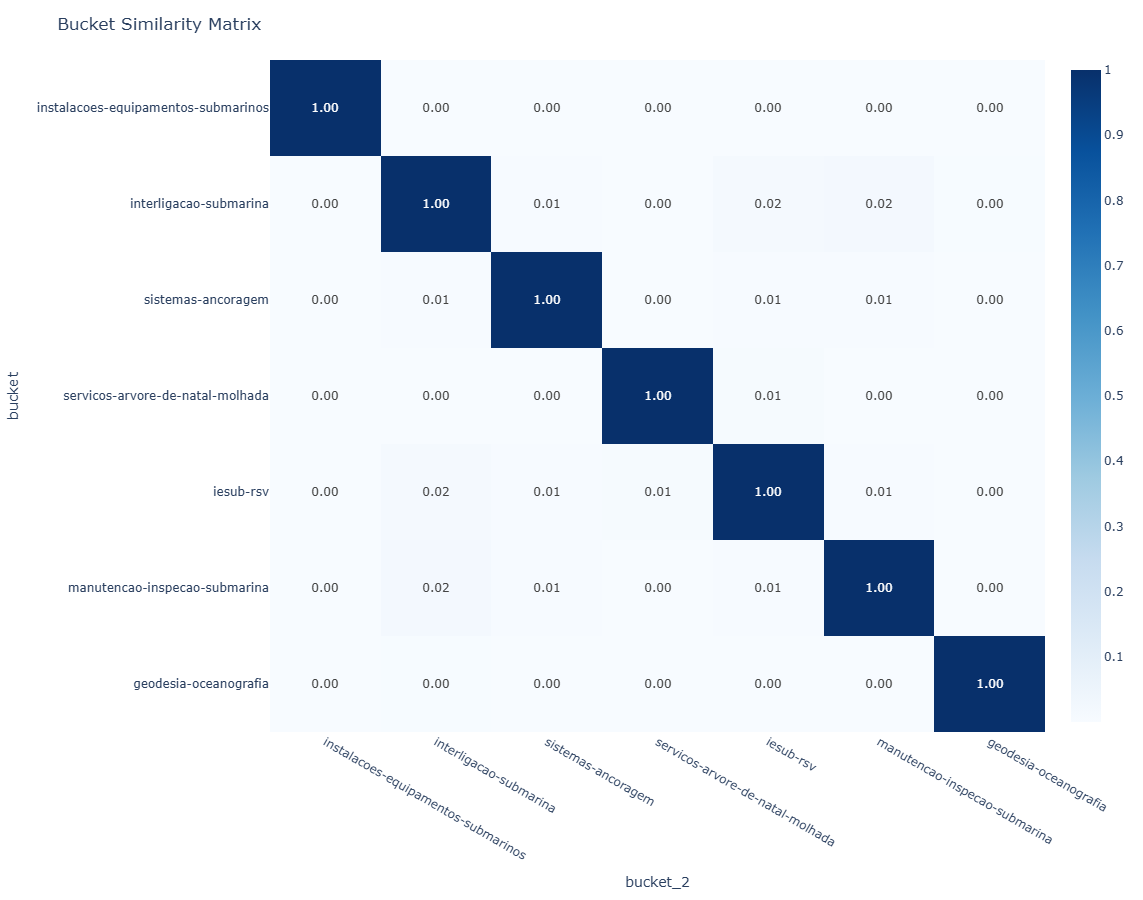

bucket_2,instalacoes-equipamentos-submarinos,interligacao-submarina,sistemas-ancoragem,servicos-arvore-de-natal-molhada,iesub-rsv,manutencao-inspecao-submarina,geodesia-oceanografia
bucket,,,,,,,
instalacoes-equipamentos-submarinos,1.000000,0.000379,0.000161,0.000772,0.001237,0.000293,0.000998
interligacao-submarina,0.000379,1.000000,0.007149,0.002508,0.015130,0.020857,0.003831
sistemas-ancoragem,0.000161,0.007149,1.000000,0.001507,0.005621,0.005990,0.001815
servicos-arvore-de-natal-molhada,0.000772,0.002508,0.001507,1.000000,0.010776,0.001345,0.000972
iesub-rsv,0.001237,0.015130,0.005621,0.010776,1.000000,0.005456,0.001617
manutencao-inspecao-submarina,0.000293,0.020857,0.005990,0.001345,0.005456,1.000000,0.001920
geodesia-oceanografia,0.000998,0.003831,0.001815,0.000972,0.001617,0.001920,1.000000


In [24]:
bucket_similarity_matrix(df)

In [34]:
df_sets = (
  df.select( [ 'bucket', 'os' ] )
    .group_by( 'bucket' )
    .agg( pl.col( 'os' ).alias( 'os_list' ) )
)

pairs = (
  df_sets.join(
    df_sets, how = 'cross', suffix = '_2'
  ).filter(
    pl.col( 'bucket' ) != pl.col( 'bucket_2' )
  )
)



bucket,os_list
cat,list[str]
"""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]"
"""sistemas-ancoragem""","[""6000792398"", ""6000792398"", … null]"
"""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]"
"""servicos-arvore-de-natal-molha…","[""6000797937"", ""6000797560"", … ""6000604185""]"
"""iesub-rsv""","[""6000780910"", ""6000780909"", … ""6000668109""]"
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]"
"""geodesia-oceanografia""","[""6000795361"", ""6000686190"", … ""6000507978""]"


In [37]:
df_sets.join( df_sets, how = 'cross', suffix = '_2' ).filter( pl.col( 'bucket' ) != pl.col( 'bucket_2' ) )

bucket,os_list,bucket_2,os_list_2
cat,list[str],cat,list[str]
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]"
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]"
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""servicos-arvore-de-natal-molha…","[""6000797937"", ""6000797560"", … ""6000604185""]"
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""iesub-rsv""","[""6000780910"", ""6000780909"", … ""6000668109""]"
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""geodesia-oceanografia""","[""6000795361"", ""6000686190"", … ""6000507978""]"
…,…,…,…
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]"
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]"
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","""servicos-arvore-de-natal-molha…","[""6000797937"", ""6000797560"", … ""6000604185""]"


In [38]:
pl.col("os_list").list.set_intersection("os_list_2").alias("intersection")

<Expr ['col("os_list").list.intersecti…'] at 0x1540631EF350>

In [39]:
pairs = pairs.with_columns([
    pl.col("os_list").list.set_intersection("os_list_2").alias("intersection"),
    pl.col("os_list").list.set_union("os_list_2").alias("union"),
    (
        pl.col("os_list").list.set_intersection("os_list_2").list.len()
        /
        pl.col("os_list").list.set_union("os_list_2").list.len()
    ).alias("similarity")
])

In [40]:
pairs

bucket,os_list,bucket_2,os_list_2,intersection,union,similarity
cat,list[str],cat,list[str],list[str],list[str],f64
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","[""6000782284"", ""6000787642"", … ""6000598748""]","[""6000792398"", ""6000795236"", … ""6000572855""]",0.007149
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]",[null],"[""6000792398"", ""6000795236"", … ""6000602544""]",0.000161
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""servicos-arvore-de-natal-molha…","[""6000797937"", ""6000797560"", … ""6000604185""]","[""6000770898"", ""6000772102"", … ""6000685762""]","[""6000792398"", ""6000795236"", … ""6000604185""]",0.001507
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""iesub-rsv""","[""6000780910"", ""6000780909"", … ""6000668109""]","[""6000790015"", ""6000749594"", … null]","[""6000792398"", ""6000795236"", … ""6000668109""]",0.005621
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""geodesia-oceanografia""","[""6000795361"", ""6000686190"", … ""6000507978""]","[""6000787689"", ""6000782913"", … ""6000560966""]","[""6000792398"", ""6000795236"", … ""6000507978""]",0.001815
…,…,…,…,…,…,…
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","[""6000759678"", ""6000785215"", … ""6000572361""]","[""6000789371"", ""6000749623"", … ""6000572855""]",0.020857
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]","[null, ""6000730018"", … ""6000612563""]","[""6000789371"", ""6000749623"", … ""6000602544""]",0.000293
"""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]","""servicos-arvore-de-natal-molha…","[""6000797937"", ""6000797560"", … ""6000604185""]","[""6000743910"", ""6000769775"", … ""6000527651""]","[""6000789371"", ""6000749623"", … ""6000652998""]",0.001345


In [44]:
( df_sets.join(df_sets, how="cross", suffix="_2")
.with_columns([
    pl.col("os_list").list.set_intersection("os_list_2").list.len().alias("inter_len"),
    pl.col("os_list").list.set_union("os_list_2").list.len().alias("union_len"),
])
.with_columns((pl.col("inter_len") / pl.col("union_len")).alias("similarity")) )

bucket,os_list,bucket_2,os_list_2,inter_len,union_len,similarity
cat,list[str],cat,list[str],u32,u32,f64
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]",5460,5460,1.0
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]",71,9932,0.007149
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""instalacoes-equipamentos-subma…","[""6000740104"", ""6000752688"", … ""6000602544""]",1,6199,0.000161
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""servicos-arvore-de-natal-molha…","[""6000797937"", ""6000797560"", … ""6000604185""]",11,7301,0.001507
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""iesub-rsv""","[""6000780910"", ""6000780909"", … ""6000668109""]",49,8718,0.005621
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""geodesia-oceanografia""","[""6000795361"", ""6000686190"", … ""6000507978""]",14,7715,0.001815
"""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]","""manutencao-inspecao-submarina""","[""6000789371"", ""6000749623"", … ""6000559301""]",252,42073,0.00599
"""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","""sistemas-ancoragem""","[""6000792398"", ""6000795236"", … ""6000559856""]",71,9932,0.007149
"""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]","""interligacao-submarina""","[""6000783348"", ""6000739414"", … ""6000572855""]",4543,4543,1.0
